Saving Dataset.csv to Dataset (1).csv
MLP Train: (17916, 6), Val: (4480, 6), Test: (5599, 6)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8614 - loss: 0.3089 - val_accuracy: 0.9462 - val_loss: 0.1240
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9615 - loss: 0.1058 - val_accuracy: 0.9830 - val_loss: 0.0520
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9786 - loss: 0.0638 - val_accuracy: 0.9911 - val_loss: 0.0365
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9926 - val_loss: 0.0306
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0365 - val_accuracy: 0.9942 - val_loss: 0.0258
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0311 - val_accuracy: 0.9942 - val_loss: 0.0250
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9946 - val_loss: 0.0238
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9920 - loss: 0.0280 - val_accuracy: 0

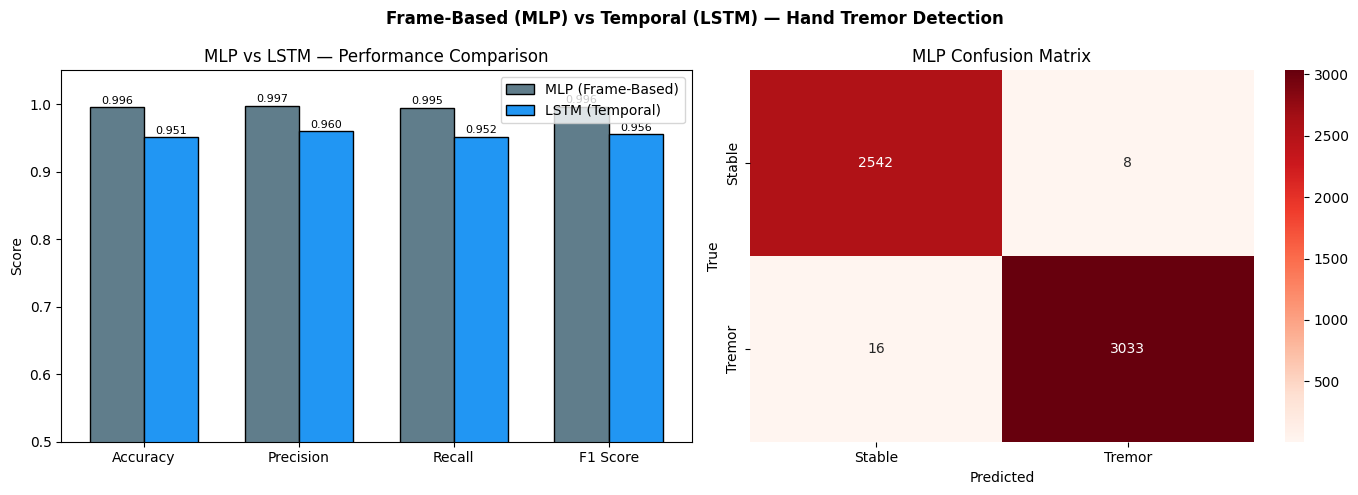


Saved mlp_vs_lstm_comparison.png


In [3]:
# ---- MLP Baseline (Frame-based, no temporal modeling) ----
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (re-upload if needed)
from google.colab import files
uploaded = files.upload()  # upload Dataset.csv if not already loaded
df = pd.read_csv('Dataset.csv')

FEATURE_COLS = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
LABEL_COL = 'Result'

X_raw = df[FEATURE_COLS].values
y_raw = df[LABEL_COL].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw);

# For MLP — use single frames (no windowing)
from sklearn.model_selection import train_test_split
X_temp, X_test_mlp, y_temp, y_test_mlp = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f'MLP Train: {X_train_mlp.shape}, Val: {X_val_mlp.shape}, Test: {X_test_mlp.shape}')

# Build MLP
def build_mlp(input_dim=6):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp()
mlp_model.summary()

# Train MLP
mlp_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                   restore_best_weights=True, mode='max'),
]

mlp_history = mlp_model.fit(
    X_train_mlp, y_train_mlp,
    validation_data=(X_val_mlp, y_val_mlp),
    epochs=50,
    batch_size=64,
    callbacks=mlp_callbacks,
    verbose=1
)

# Evaluate MLP
y_pred_mlp = (mlp_model.predict(X_test_mlp) > 0.5).astype(int).flatten()
mlp_acc  = accuracy_score(y_test_mlp, y_pred_mlp)
mlp_prec = precision_score(y_test_mlp, y_pred_mlp)
mlp_rec  = recall_score(y_test_mlp, y_pred_mlp)
mlp_f1   = f1_score(y_test_mlp, y_pred_mlp)

print('\n===== MLP (Frame-Based) Results =====')
print(f'Accuracy:  {mlp_acc:.4f}')
print(f'Precision: {mlp_prec:.4f}')
print(f'Recall:    {mlp_rec:.4f}')
print(f'F1 Score:  {mlp_f1:.4f}')

# LSTM results from previous run
lstm_acc  = 0.9509
lstm_prec = 0.9597
lstm_rec  = 0.9520
lstm_f1   = 0.9558

# Comparison table
print('\n===== FINAL COMPARISON: MLP vs LSTM =====')
comparison = pd.DataFrame({
    'Model': ['MLP (Frame-Based)', 'LSTM (Temporal)'],
    'Accuracy':  [round(mlp_acc, 4),  lstm_acc],
    'Precision': [round(mlp_prec, 4), lstm_prec],
    'Recall':    [round(mlp_rec, 4),  lstm_rec],
    'F1 Score':  [round(mlp_f1, 4),   lstm_f1],
    'Temporal':  ['No', 'Yes']
})
print(comparison.to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
mlp_vals  = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]
lstm_vals = [lstm_acc, lstm_prec, lstm_rec, lstm_f1]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0].bar(x - width/2, mlp_vals,  width, label='MLP (Frame-Based)', color='#607D8B', edgecolor='black')
bars2 = axes[0].bar(x + width/2, lstm_vals, width, label='LSTM (Temporal)',   color='#2196F3', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('MLP vs LSTM — Performance Comparison')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Confusion matrices side by side
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Stable', 'Tremor'], yticklabels=['Stable', 'Tremor'])
axes[1].set_title('MLP Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('Frame-Based (MLP) vs Temporal (LSTM) — Hand Tremor Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_vs_lstm_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSaved mlp_vs_lstm_comparison.png')
